<a href="https://colab.research.google.com/github/ShritisnigdhaMishra/AML_LAB/blob/main/MultipleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Suppose we want to predict the final exam marks of the student.instead of using only one factor we use 3 factors study hours,attendance(%),assignment mark.Apply the mlr to predict the final marks using libraries numpy,panda,matplot and scikit-learn.

Enter the name of the target variable(Y):Final marks
Enter comma-separated numerical values for Final marks: 45,60,75,90
How many feature variables do you want to enter:3

Enter comma separated values for each feature:
Enter the name of feature X1:Study hours
Enter values for Study hours:2,4,6,8
Enter the name of feature X2:Attendance
Enter values for Attendance:70,80,85,90
Enter the name of feature X3:Assignment
Enter values for Assignment:12,15,18,20

Final Regression Equation
Final marks=30.0000+7.5000*Study hours+-0.0000*Attendance+0.0000*Assignment

Intercept(b): 30.0
Slope for Study hours:7.5000
Slope for Attendance:-0.0000
Slope for Assignment:0.0000

Performance Metrics
MSE:0.0000
MAE:0.0000
RMSE:0.0000
R2 Score:1.0000

Do you want to predict Final marks?(yes/no):yes

Enter values for prediction
Study hours:6
Attendance:85
Assignment:18

Predicted Final marks:75.0000


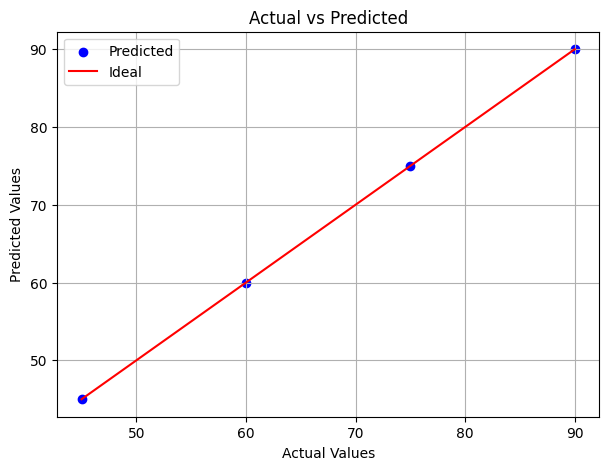

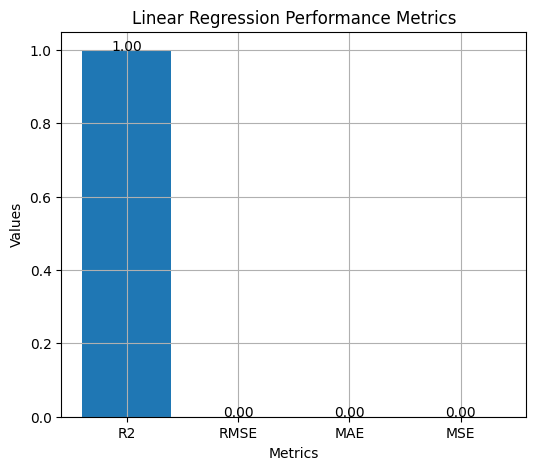

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
y_name=input("Enter the name of the target variable(Y):").strip()
y_input=input(f"Enter comma-separated numerical values for {y_name}: ")
y_vals=np.array([float(val) for val in y_input.split(",") if val.strip()])
num_data_points=len(y_vals)
num_features=int(input("How many feature variables do you want to enter:"))
x_data={}
x_names=[]
validation_passed=True
print("\nEnter comma separated values for each feature:")
for i in range(num_features):
    feat_name=input(f"Enter the name of feature X{i+1}:").strip()
    x_names.append(feat_name)
    feat_input=input(f"Enter values for {feat_name}:")
    feat_vals=np.array([float(val) for val in feat_input.split(",") if val.strip()])
    if len(feat_vals)!=num_data_points:
        print(f"\nError:'{feat_name}'has {len(feat_vals)} values but '{y_name}' has {num_data_points}.")
        validation_passed=False
        break
    x_data[feat_name]=feat_vals
if not validation_passed:
    print("Execution stopped due to mismatched data length.")
    exit()
if num_data_points<2:
    print("Please enter at least two data points.")
    exit()
data=pd.DataFrame(x_data)
model=LinearRegression()
model.fit(data,y_vals)
predictions=model.predict(data)
mse=mean_squared_error(y_vals,predictions)
mae=mean_absolute_error(y_vals,predictions)
rmse=np.sqrt(mse)
r2=r2_score(y_vals,predictions)
intercept=model.intercept_
coefficients=model.coef_
equation_terms=[
    f"{coeff:.4f}*{name}"
    for coeff,name in zip(coefficients,x_names)
]
equation=f"{y_name}={intercept:.4f}+"+"+".join(equation_terms)
print("\nFinal Regression Equation")
print(equation)
print("\nIntercept(b):",round(intercept,4))
for name,coeff in zip(x_names,coefficients):
    print(f"Slope for {name}:{coeff:.4f}")
print("\nPerformance Metrics")
print(f"MSE:{mse:.4f}")
print(f"MAE:{mae:.4f}")
print(f"RMSE:{rmse:.4f}")
print(f"R2 Score:{r2:.4f}")
choice=input(f"\nDo you want to predict {y_name}?(yes/no):").strip().lower()
if choice in ["yes","y"]:
    sample={}
    print("\nEnter values for prediction")
    for name in x_names:
        value=float(input(f"{name}:"))
        sample[name]=[value]
    sample_df=pd.DataFrame(sample)
    prediction=model.predict(sample_df)
    print(f"\nPredicted {y_name}:{prediction[0]:.4f}")
plt.figure(figsize=(7,5))
plt.scatter(y_vals,predictions,color="blue",label="Predicted")
min_val=min(min(y_vals),min(predictions))
max_val=max(max(y_vals),max(predictions))
plt.plot([min_val,max_val],
         [min_val,max_val],
         color="red",
         label="Ideal")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()
metrics=["R2","RMSE","MAE","MSE"]
values=[r2,rmse,mae,mse]
plt.figure(figsize=(6,5))
plt.bar(metrics,values)
for i,val in enumerate(values):
    plt.text(i,val,f"{val:.2f}",ha="center")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.title("Linear Regression Performance Metrics")
plt.grid(True)
plt.show()